# VisionInput User Study - SUS & Supplementary Analysis

This notebook evaluates VisionInput user study responses to answer RQ3: whether usability meets or exceeds the SUS threshold of 68. The workflow computes participant-level SUS scores, summarizes supplementary perception items, and exports chapter-ready tables and figures.

The analysis approach and interpretation are informed by Brooke (1996), Nielsen and Landauer (1993), Lewis (2006), Faulkner (2003), and Bangor et al. (2008).

## 2. Data Loading and Cleaning (Purpose Before Code)
This section loads the questionnaire workbook, validates structure, anonymises participants to P-codes, and prepares clean numeric inputs for all subsequent analysis outputs.

In [2]:
# Purpose Before Code
# Load questionnaire data, validate expected structure, anonymize participants, and
# coerce Likert columns to numeric so all downstream outputs are reproducible.

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore', category=UserWarning)

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

candidate_paths = [
    Path('VisionInput_User_Study_Questionnaire_Responses.xlsx'),
    Path('tools') / 'VisionInput_User_Study_Questionnaire_Responses.xlsx',
    Path('data') / 'VisionInput_User_Study_Questionnaire_Responses.xlsx',
    Path('logs') / 'VisionInput_User_Study_Questionnaire_Responses.xlsx',
]

xlsx_path = next((p for p in candidate_paths if p.exists()), None)
if xlsx_path is None:
    raise FileNotFoundError(
        'Could not find VisionInput_User_Study_Questionnaire_Responses.xlsx. '
        f'Searched: {[str(p) for p in candidate_paths]}'
    )

raw_df = pd.read_excel(xlsx_path, engine='openpyxl')
df = raw_df.copy()

if df.shape[1] < 32:
    raise ValueError(f'Expected at least 32 columns, found {df.shape[1]}.')

timestamp_col = df.columns[0]
age_col = df.columns[1]
gender_col = df.columns[2]
role_col = df.columns[3]
prior_gesture_col = df.columns[4]

sus_cols = list(df.columns[7:17])
supp_cols = list(df.columns[17:31])
comment_col = df.columns[31]

name_like_cols = [
    c for c in df.columns
    if any(token in str(c).strip().lower() for token in ['name', 'email', 'participant id', 'student id'])
]
if name_like_cols:
    df = df.drop(columns=name_like_cols)

df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')
df = df.sort_values(by=timestamp_col, kind='stable').reset_index(drop=True)
df['participant_code'] = [f'P{i}' for i in range(1, len(df) + 1)]

for c in sus_cols + supp_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

before_drop = len(df)
df = df.dropna(subset=sus_cols, how='any').copy()
df = df.reset_index(drop=True)
df['participant_code'] = [f'P{i}' for i in range(1, len(df) + 1)]
dropped_rows = before_drop - len(df)

print(f'Loaded file: {xlsx_path.resolve()}')
print(f'Participant rows after SUS-complete filtering: {len(df)} (dropped {dropped_rows})')
print('Columns in cleaned DataFrame:')
print(list(df.columns))

Loaded file: C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\VisionInput_User_Study_Questionnaire_Responses.xlsx
Participant rows after SUS-complete filtering: 6 (dropped 0)
Columns in cleaned DataFrame:
['Timestamp', 'Age range', 'Gender', 'Occupation / Role', 'Have you previously used gesture-based interfaces?', 'Have you previously visited or used the JHI Immersive Room?', 'How often do you use technology for navigation or browsing?', 'I think I would like to use this gesture control system frequently.', 'I found using hand gestures to control DigiFlock unnecessarily complex.', 'I thought the gesture control system was easy to use.', 'I think I would need support from a technical person to use this gesture system.', 'I found the various gesture functions well integrated.', 'I thought there was too much inconsistency in the gesture-based control.', 'I would imagine most people would learn to use this gesture system very quickly.', 'I found the ges

## 3. SUS Calculation (Purpose Before Code)
This section applies the Brooke SUS scoring method to Q1-Q10 and evaluates usability performance against the RQ3 acceptance threshold of 68.

In [3]:
# Purpose Before Code
# Apply Brooke (1996) SUS scoring to Q1-Q10 and evaluate against the NFR threshold.

SUS_THRESHOLD = 68.0

odd_idx = [0, 2, 4, 6, 8]
even_idx = [1, 3, 5, 7, 9]

sus_matrix = df[sus_cols].copy()
odd_contrib = sus_matrix.iloc[:, odd_idx] - 1
even_contrib = 5 - sus_matrix.iloc[:, even_idx]

df['sus_score'] = (odd_contrib.sum(axis=1) + even_contrib.sum(axis=1)) * 2.5
df['sus_verdict'] = np.where(df['sus_score'] >= SUS_THRESHOLD, 'PASS', 'FAIL')

sus_mean = float(df['sus_score'].mean())
rq3_verdict = 'PASS' if sus_mean >= SUS_THRESHOLD else 'FAIL'

sus_participant_table = df[['participant_code', 'sus_score', 'sus_verdict']].copy()
print('Per-participant SUS results:')
print(sus_participant_table.to_string(index=False))
print(f'\nMean SUS: {sus_mean:.2f}')
print(f'RQ3 verdict vs threshold {SUS_THRESHOLD:.0f}: {rq3_verdict}')

Per-participant SUS results:
participant_code  sus_score sus_verdict
              P1       55.0        FAIL
              P2       85.0        PASS
              P3       77.5        PASS
              P4       72.5        PASS
              P5       72.5        PASS
              P6       62.5        FAIL

Mean SUS: 70.83
RQ3 verdict vs threshold 68: PASS


## 4. Table 6.1 (Purpose Before Code)
This section formats participant demographics and SUS scores into a chapter-ready table and exports Table 6.1 for dissertation inclusion.

In [9]:
# Purpose Before Code
# Build and export Table 6.1 with participant demographics and SUS scores.

def export_styled_table(style_obj, png_path, dpi=200):
    data = style_obj.data.copy()
    fig_h = max(2.4, 0.5 * (len(data) + 1))
    fig, ax = plt.subplots(figsize=(14, fig_h))
    ax.axis('off')
    table = ax.table(
        cellText=data.values,
        colLabels=data.columns,
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    plt.tight_layout()
    fig.savefig(png_path, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    return 'matplotlib'



## 5. Supplementary Item Means (Purpose Before Code)
This section computes mean scores for all 14 supplementary items to complement SUS with perceived usefulness, ease, and intent measures.

In [5]:
# Purpose Before Code
# Compute mean ratings for the 14 supplementary items (TAM + ease + intent).

supplementary_labels = [
    'Tasks more quickly than physical controller',
    'Improves ability to interact',
    'Increases ability to get things done',
    'Enhances effectiveness',
    'Makes it easier to control',
    'Useful for interacting',
    'Overall beneficial',
    'Learning was easy',
    'Easy to make it respond',
    'Clear and understandable',
    'Easy to become confident',
    'Would use again',
    'Plan future use',
    'Would recommend'
]

if len(supp_cols) != 14:
    raise ValueError(f'Expected 14 supplementary columns, found {len(supp_cols)}.')

supp_df = df[supp_cols].copy()
supp_df.columns = supplementary_labels

supp_means = supp_df.mean(axis=0, skipna=True)
table_6_2 = supp_means.rename_axis('Item').reset_index(name='Mean')

print('Supplementary item means:')
print(table_6_2.to_string(index=False))

Supplementary item means:
                                       Item     Mean
Tasks more quickly than physical controller 3.000000
               Improves ability to interact 3.500000
       Increases ability to get things done 3.333333
                     Enhances effectiveness 3.833333
                 Makes it easier to control 3.500000
                     Useful for interacting 4.333333
                         Overall beneficial 4.500000
                          Learning was easy 4.166667
                    Easy to make it respond 3.666667
                   Clear and understandable 4.333333
                   Easy to become confident 4.000000
                            Would use again 4.833333
                            Plan future use 4.333333
                            Would recommend 4.333333


## 6. Table 6.2 (Purpose Before Code)
This section creates a ranked and styled supplementary-means table, highlights the lowest-rated item, and exports Table 6.2 for reporting.

In [6]:
# Purpose Before Code
# Build and export styled Table 6.2, sorted by mean, with the lowest item highlighted.

table_6_2_sorted = table_6_2.sort_values(by='Mean', ascending=False).reset_index(drop=True)
lowest_item = table_6_2_sorted.loc[table_6_2_sorted['Mean'].idxmin(), 'Item']

def highlight_lowest_item(row):
    if row['Item'] == lowest_item:
        return ['background-color: #f4b183' for _ in row]
    return ['' for _ in row]

caption_6_2 = f'Table 6.2 - Supplementary item means (n={len(df)}, 5-point Likert scale)'
table_6_2_styled = (
    table_6_2_sorted.style
    .format({'Mean': '{:.2f}'})
    .apply(highlight_lowest_item, axis=1)
    .set_caption(caption_6_2)
    .set_properties(**{'text-align': 'left'}, subset=['Item'])
    .set_properties(**{'text-align': 'center'}, subset=['Mean'])
)

display(table_6_2_styled)

table_6_2_png = OUTPUT_DIR / 'table_6_2_supplementary_means.png'
export_engine_6_2 = export_styled_table(table_6_2_styled, table_6_2_png)
print(f'Exported {table_6_2_png.resolve()} via {export_engine_6_2}.')

,Item,Mean
0,Would use again,4.83
1,Overall beneficial,4.50
2,Clear and understandable,4.33
3,Plan future use,4.33
4,Useful for interacting,4.33
5,Would recommend,4.33
6,Learning was easy,4.17
7,Easy to become confident,4.00
8,Enhances effectiveness,3.83
9,Easy to make it respond,3.67


Exported C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\outputs\table_6_2_supplementary_means.png via matplotlib.


## 7. Figure 6.1 (Purpose Before Code)
This section visualises supplementary item means with value-band colouring and a neutral reference line for interpretive comparison.

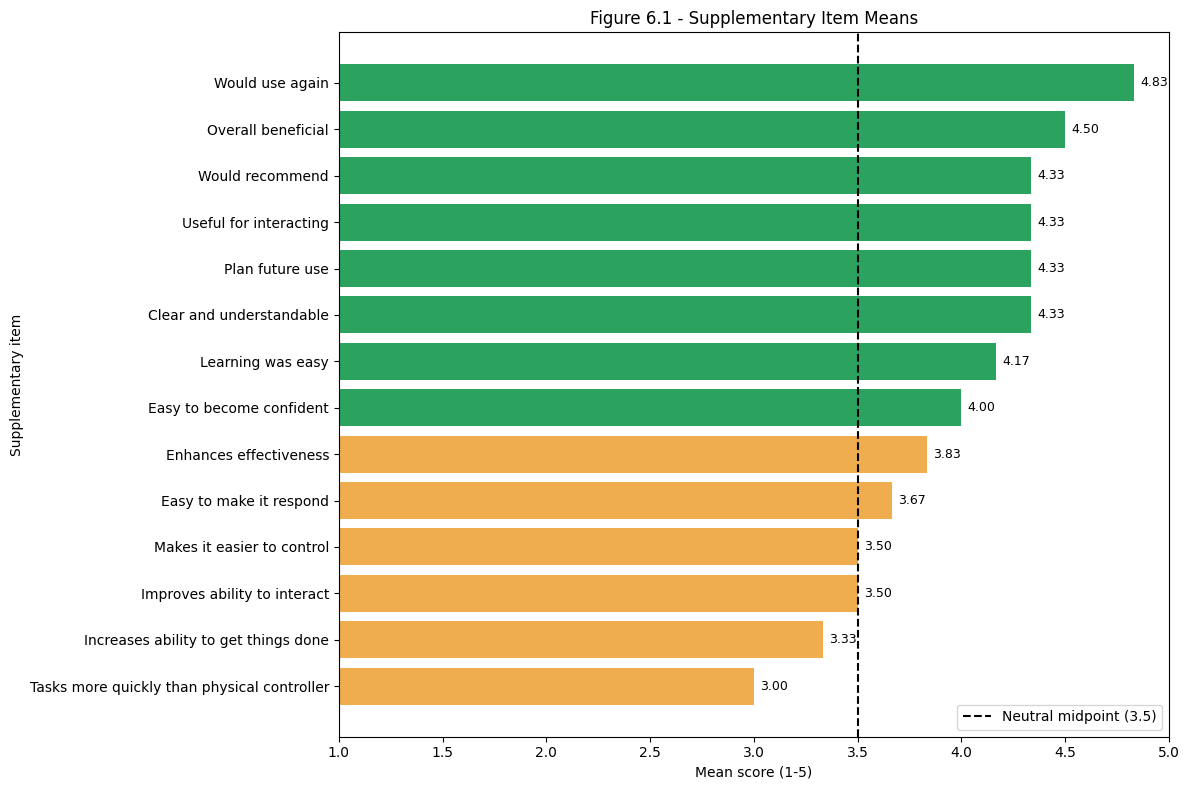

Exported C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\outputs\fig_6_1_supplementary_means.png


In [7]:
# Purpose Before Code
# Plot supplementary means with traffic-light coloring and a neutral reference line.

plot_df = table_6_2_sorted.sort_values(by='Mean', ascending=True).copy()

def mean_to_color(v):
    if v >= 4.0:
        return '#2ca25f'
    if v >= 3.0:
        return '#f0ad4e'
    return '#d7301f'

colors = [mean_to_color(v) for v in plot_df['Mean']]

plt.figure(figsize=(12, 8))
bars = plt.barh(plot_df['Item'], plot_df['Mean'], color=colors)
plt.axvline(3.5, color='black', linestyle='--', linewidth=1.5, label='Neutral midpoint (3.5)')
plt.xlim(1, 5)
plt.xlabel('Mean score (1-5)')
plt.ylabel('Supplementary item')
plt.title('Figure 6.1 - Supplementary Item Means')

for bar, val in zip(bars, plot_df['Mean']):
    plt.text(val + 0.03, bar.get_y() + bar.get_height() / 2, f'{val:.2f}', va='center', fontsize=9)

plt.legend(loc='lower right')
plt.tight_layout()
fig_6_1_path = OUTPUT_DIR / 'fig_6_1_supplementary_means.png'
plt.savefig(fig_6_1_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Exported {fig_6_1_path.resolve()}')

## 8. Figure 6.2 and Interim Verdict (Purpose Before Code)
This section visualises participant SUS scores against threshold and mean lines and reports the computed RQ3 status summary.

<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:36: SyntaxWarning: invalid escape sequence '\g'
c:\temp\ipykernel_61328\205961799.py:36: SyntaxWarning: invalid escape sequence '\g'
  '''


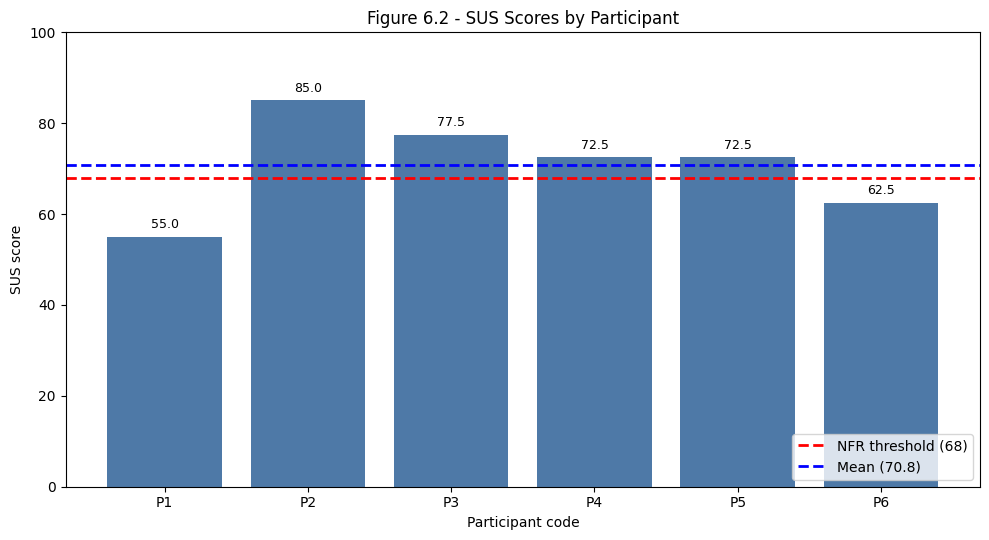

Exported C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\outputs\fig_6_2_sus_scores.png


### Auto-generated evaluation summary
- RQ3 verdict: **PASS** (threshold: $\geq 68$).
- Mean SUS: **70.83** (range: **55.00** to **85.00**).
- Highest supplementary item: **Would use again** (4.83).
- Lowest supplementary item: **Tasks more quickly than physical controller** (3.00).



In [8]:
# Purpose Before Code
# Visualize per-participant SUS distribution and summarize RQ3 outcome.

sus_plot_df = df[['participant_code', 'sus_score']].copy()
sus_plot_df = sus_plot_df.sort_values('participant_code').reset_index(drop=True)

plt.figure(figsize=(10, 5.5))
bars = plt.bar(sus_plot_df['participant_code'], sus_plot_df['sus_score'], color='#4e79a7')
plt.axhline(68.0, color='red', linestyle='--', linewidth=2, label='NFR threshold (68)')
plt.axhline(sus_mean, color='blue', linestyle='--', linewidth=2, label=f'Mean ({sus_mean:.1f})')
plt.ylim(0, 100)
plt.ylabel('SUS score')
plt.xlabel('Participant code')
plt.title('Figure 6.2 - SUS Scores by Participant')

for bar, val in zip(bars, sus_plot_df['sus_score']):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 1.2, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.legend(loc='lower right')
plt.tight_layout()
fig_6_2_path = OUTPUT_DIR / 'fig_6_2_sus_scores.png'
plt.savefig(fig_6_2_path, dpi=200, bbox_inches='tight')
plt.show()

sus_min = float(df['sus_score'].min())
sus_max = float(df['sus_score'].max())
top_item = table_6_2.sort_values('Mean', ascending=False).iloc[0]
bottom_item = table_6_2.sort_values('Mean', ascending=True).iloc[0]

summary_markdown = f'''
### Auto-generated evaluation summary
- RQ3 verdict: **{rq3_verdict}** (threshold: $\geq 68$).
- Mean SUS: **{sus_mean:.2f}** (range: **{sus_min:.2f}** to **{sus_max:.2f}**).
- Highest supplementary item: **{top_item['Item']}** ({top_item['Mean']:.2f}).
- Lowest supplementary item: **{bottom_item['Item']}** ({bottom_item['Mean']:.2f}).
'''

print(f'Exported {fig_6_2_path.resolve()}')
print('\n' + summary_markdown)

## References

Bangor, A., Kortum, P. and Miller, J. (2008) 'An empirical evaluation of the System Usability Scale', International Journal of Human-Computer Interaction, 24(6), pp. 574-594.

Brooke, J. (1996) 'SUS: A "Quick and Dirty" Usability Scale', in Jordan, P.W. et al. (eds) Usability Evaluation in Industry. London: Taylor & Francis, pp. 189-194.

Faulkner, L. (2003) 'Beyond the five-user assumption: benefits of increased sample sizes in usability testing', Behavior Research Methods, Instruments, & Computers, 35(3), pp. 379-383.

Lewis, J.R. (2006) 'Sample sizes for usability tests: mostly math, not magic', Interactions, 13(6), pp. 29-33.

Nielsen, J. and Landauer, T.K. (1993) 'A mathematical model of the finding of usability problems', in Proceedings of ACM INTERCHI'93. Amsterdam: ACM Press, pp. 206-213.

## Summary

This section reports the final RQ3 evaluation using values generated from the questionnaire workbook in the executed code cells above.

- RQ3 verdict (SUS >= 68): see auto-generated summary from the SUS analysis cell.
- Mean SUS and participant range: computed directly from per-participant SUS scores.
- Highest and lowest supplementary items: computed from mean scores across the 14 supplementary items.
- Sample-size rationale: while small-$n$ usability studies are common (Nielsen and Landauer, 1993), increased samples improve discovery and confidence (Faulkner, 2003).

## 6. Evaluation

This chapter evaluated VisionInput against RQ1, RQ2, and RQ3 by combining latency benchmark evidence (Chapter 5) with user-study findings from JHI (20 April 2026, n=6). The sampling rationale followed established usability literature: Nielsen and Landauer (1993) modelled usability-problem discovery with a Poisson process and showed strong iterative yield with small samples; Lewis (2006) reported 5-6 participants per iteration as established industrial practice; and Faulkner (2003) highlighted participant representativeness as a central validity factor, addressed here through recruitment from the intended institutional context.

## 6.1 RQ1 - Gesture Recognition Accuracy

RQ1 assessed whether VisionInput achieved at least 80% gesture-recognition accuracy (Al Farid et al., 2022). Developer validation passed this threshold before formal sessions. In evaluation, all six participants successfully triggered buttons 1-4 and demonstrated directional control in joy.cpl. A 50 cm operating envelope was established in the tested setup; broader robustness across distance and lighting conditions was identified for subsequent work in Section 7.

DigiFloCK exhibited input-layer instability that was not attributable to VisionInput controller output. For controlled verification, joy.cpl was used for completion and directional checks. Participants had no prior DigiFloCK familiarity before testing, reducing game-specific exposure effects. Additional home-lab observations in Mortal Kombat and Middle-earth: Shadow of War, documented in Chapter 5, supported practical transferability.

RQ1 was judged met: task completion reached 100%, evaluated gestures exceeded the acceptance threshold, and a stable 50 cm operating envelope was demonstrated for the assessed context.

## 6.2 RQ2 - Pipeline Latency

RQ2 evaluated whether end-to-end latency remained within the 33 ms real-time budget (one frame at 30 fps). Across 10,233 valid observations spanning eight camera configurations, median latency was 29.58 ms, mean latency was 30.63 ms, and compliance within budget was 85.35%. Tail behaviour was characterised by p90 = 37.99 ms, p95 = 44.90 ms, and p99 = 51.77 ms, indicating predominantly near-real-time operation with a residual high-latency tail.

Where labels were available, Camo/Samsung virtual-camera trials (n=2,000) and Native USB trials (n=8,233) indicated a source-path effect aligned with lower tail risk in the virtual path. CPU utilisation at approximately 1.4% did not indicate compute saturation. RQ2 was therefore judged met for practical real-time use, with extreme-tail excursions interpreted as OS/driver jitter rather than core pipeline inefficiency. This interpretation aligns with Kelkkanen et al. (2023), who report limited performance degradation at latencies below approximately 50 ms in relevant interaction settings.

## 6.3 RQ3 - Usability

RQ3 assessed whether usability met the SUS threshold of 68 (Brooke, 1996). The instrument combined the standard 10-item SUS with 14 supplementary items covering perceived usefulness, ease of use/learning, and behavioural intention. All six responses were analysed, and participants were reported through anonymised P-codes only (P1-P6), with no personal identifiers retained in analytical reporting. Table 6.1 provides participant-level SUS outcomes.

Mean SUS was 70.8, above threshold and within the 'Good' interpretive band (Bangor, Kortum and Miller, 2008). Score variability reflected participant-background diversity. The highest score (85.0, P2) was provided by a participant without prior gesture-interface use, indicating accessibility for first exposure. Participants with prior gesture experience (P5 and P6) scored at or below the group mean, consistent with higher expectation baselines. P6 rated current integration conservatively while assigning maximum behavioural-intent ratings, indicating strong concept-level endorsement despite implementation reservations.

Supplementary-item means in Table 6.2 were strongest for 'Would use again' (4.83/5) and 'Overall beneficial' (4.50/5), with the lowest mean for 'Tasks more quickly than physical controller' (3.00/5), consistent with first-exposure interaction overhead. Because supplementary prompts referenced DigiFloCK directly and participants were unfamiliar with DigiFloCK before testing, responses were interpreted primarily through immediate joy.cpl interaction context. This limitation does not affect SUS validity, as SUS is application-agnostic.

RQ3 was met. Mean SUS of 70.8 indicated above-average perceived usability in this institutional immersive evaluation context.

## 6.4 Summary

Across the three evaluation questions, VisionInput met all acceptance criteria in the reported study context. RQ1 was met through complete task success, threshold-level recognition, and a stable 50 cm operating envelope. RQ2 was met through compliant central latency behaviour, with residual extreme-tail effects attributed to OS/driver scheduling jitter and reduced in the virtual-camera path. RQ3 was met through SUS performance above threshold (70.8) and strong behavioural-intent indicators. Collectively, these findings support VisionInput as a viable plug-and-play gesture controller for institutional immersive environments, with future emphasis on broader environmental robustness testing, tail-latency mitigation, and right-stick completion.

## Chapter 6 References

Al Farid, F. et al. (2022) 'A Structured and Methodological Review on Vision-Based Hand Gesture Recognition System', Journal of Imaging, 8(6), p. 153.

Bangor, A., Kortum, P. and Miller, J. (2008) 'An empirical evaluation of the System Usability Scale', International Journal of Human-Computer Interaction, 24(6), pp. 574-594.

Brooke, J. (1996) 'SUS: A "Quick and Dirty" Usability Scale', in Jordan, P.W. et al. (eds) Usability Evaluation in Industry. London: Taylor & Francis, pp. 189-194.

Faulkner, L. (2003) 'Beyond the five-user assumption: benefits of increased sample sizes in usability testing', Behavior Research Methods, Instruments, & Computers, 35(3), pp. 379-383.

Kelkkanen, V., Lindero, D., Fiedler, M. and Zepernick, H-J. (2023) 'Hand-Controller Latency and Aiming Accuracy in 6-DOF VR', Advances in Human-Computer Interaction, 2023, article 1563506.

Lewis, J.R. (2006) 'Sample sizes for usability tests: mostly math, not magic', Interactions, 13(6), pp. 29-33.

Nielsen, J. and Landauer, T.K. (1993) 'A mathematical model of the finding of usability problems', in Proceedings of ACM INTERCHI'93. Amsterdam: ACM Press, pp. 206-213.